In [5]:
import numpy as np

import KratosMultiphysics
from KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_analysis import StructuralMechanicsAnalysis

from pathlib import Path


with open("problem.json", "r") as kratos_input:
    parameters = KratosMultiphysics.Parameters(kratos_input.read())


model = KratosMultiphysics.Model()
simulation = StructuralMechanicsAnalysis(model, parameters)
simulation.Run()

::[MechanicalSolver]:: : Construction finished 
::[StaticMechanicalSolver]:: : Construction finished 
::[MechanicalSolver]:: : Variables ADDED 
::[PythonSolver]::: Reading model part. 
SingleImportModelPart: Reading model part from file: "/home/srosenbu/git-packages/one-element-test/kratos/mesh".mdpa
ModelPartIO:   [Reading Nodes    : 8 nodes read]
ModelPartIO:   [Reading Elements : 1 elements read] [Type: TotalLagrangianElement3D8N]
ModelPartIO:   [Total Lines Read : 44]
SingleImportModelPart: Finished reading model part from mdpa file.
ModelPart: -Structure- model part
    Buffer Size : 1
    Number of tables : 0
    Number of sub model parts : 3
    Current solution step index : 0
    DOMAIN_SIZE : 3
    OSS_SWITCH : 0
    IS_RESTARTED : 0

    Number of Geometries  : 0
    Mesh 0 :
        Number of Nodes       : 8
        Number of Properties  : 1
        Number of Elements    : 1
        Number of Conditions  : 0
        Number of Constraints : 0

    -DISPLACEMENT_FixedFace- mod

## EQUATIONS GENERATED BY COPILOT: Theory: Kratos Drucker-Prager Formulation

Kratos' Drucker-Prager implementation is based on a pressure-sensitive yield surface with a separate plastic potential. In the structural mechanics constitutive law, the model uses the material parameters `FRICTION_ANGLE` $\phi$ and `DILATANCY_ANGLE` $\psi$, together with the elastic constants $E$ and $\nu$.

For a stress tensor $\sigma$, the invariants are

$$
I_1 = \operatorname{tr}(\sigma), \qquad
J_2 = \tfrac{1}{2} \, s:s, \qquad
s = \sigma - \tfrac{1}{3} I_1 \, \mathbf{I}.
$$

The Kratos Drucker-Prager yield function can be written in the form

$$
f(\sigma) = C_{FL}(\phi)\left(\sqrt{J_2} + \frac{2 I_1 \sin\phi}{\sqrt{3}\,(3-\sin\phi)}\right) - \sigma_{\mathrm{u},0},
$$

with the yield condition

$$
f(\sigma) \le 0.
$$

Here

$$
C_{FL}(\phi) = -\frac{\sqrt{3}\,(3-\sin\phi)}{3\sin\phi - 3},
$$

and the uniaxial threshold is defined from the tensile strength and friction angle as

$$
\sigma_{\mathrm{u},0} = \left|\,\sigma_t \, \frac{3 + \sin\phi}{3\sin\phi - 3}\,\right|.
$$

This is the scalar form behind the Kratos yield-surface implementation, which compares the stress state against the uniaxial threshold through the equivalent-stress mapping.

For non-associated flow, Kratos uses a Drucker-Prager plastic potential with the dilatancy angle $\psi$. The same structure appears in the derivative of the plastic potential, but with $\psi$ replacing $\phi$:

$$
\frac{\partial g}{\partial \sigma} = c_1 \, \mathbf{V}_1 + c_2 \, \mathbf{V}_2,
$$

$$
c_1 = C_{FL}(\psi)\,\frac{2\sin\psi}{\sqrt{3}\,(3-\sin\psi)}, \qquad
c_2 = C_{FL}(\psi),
$$

with the volumetric and deviatoric directions assembled from the stress invariants in the Kratos implementation. When $\psi = \phi$, the response becomes associated flow.

For this notebook, the Kratos input deck is set up to match the FEniCS example on the same unit cube and loading path, so the comparison is directly between the two implementations under the same uniaxial-strain-style test.

## Postprocessing: Stress-Strain Response and Plastic Strain Evolution

Extract results from the simulation and compare with elastic reference response.

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load results from JSON
with open("result.json", "r") as f:
    results = json.load(f)

# Extract time steps and data
time_steps = np.array(results["TIME"])
n_steps = len(time_steps)

# Extract stress and plastic strain from ELEMENT_1 (integration point 0)
cauchy_stress = np.array(results["ELEMENT_1"]["CAUCHY_STRESS_VECTOR"]["0"])
plastic_strain = np.array(results["ELEMENT_1"]["PLASTIC_STRAIN_VECTOR"]["0"])

# Stress and strain components: [xx, yy, zz, xy, xz, yz]
sigma_xx = cauchy_stress[:, 0]  # Axial stress
alpha_accumulated = np.zeros(n_steps)

# For a uniaxial strain test, the accumulated plastic strain can be extracted
# from the plastic strain vector. The effective accumulated strain is related to
# the norm of the plastic strain deviator.
for i in range(n_steps):
    # Accumulate the plastic strain based on the equivalent plastic strain
    eps_p = plastic_strain[i]
    alpha_accumulated[i] = np.linalg.norm(eps_p)

# Compute applied strain
# Loading from problem.json: displacement = 0.0005*t, end_time=60.0, so max_disp=0.03 on unit cube
eps_xx = time_steps * 0.0005  # matches fenics: max_disp=0.03 over 60 steps

# Material properties from material.json (matched to FEniCS example)
E = 3.0e4
nu = 0.2
mu = E / (2.0 * (1.0 + nu))
kappa = E / (3.0 * (1.0 - 2.0 * nu))
C11 = kappa + 4.0 * mu / 3.0

# Elastic reference response
sigma_elastic_ref = C11 * eps_xx

print(f"Number of load steps: {n_steps}")
print(f"Final sigma_xx: {sigma_xx[-1]:.3e} Pa")
print(f"Final accumulated plastic strain: {alpha_accumulated[-1]:.6f}")
print(f"Elastic modulus C11: {C11:.3e} Pa")

Number of load steps: 30
Final sigma_xx: 1.588e+02 Pa
Final accumulated plastic strain: 0.026404
Elastic modulus C11: 3.333e+04 Pa


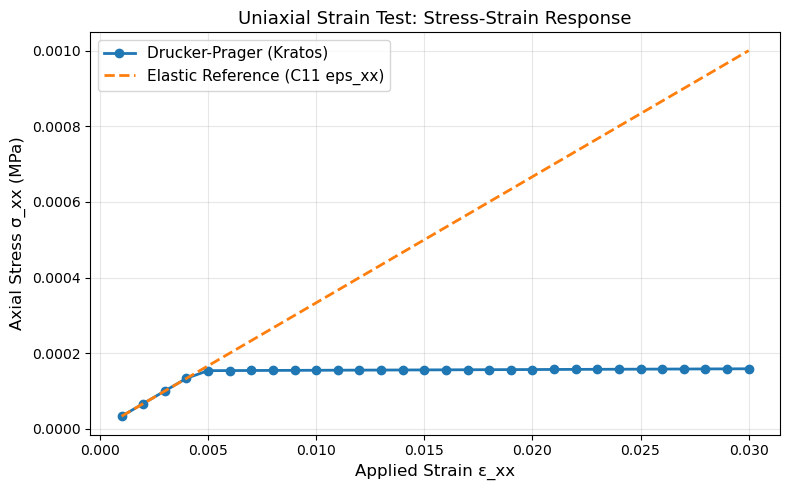

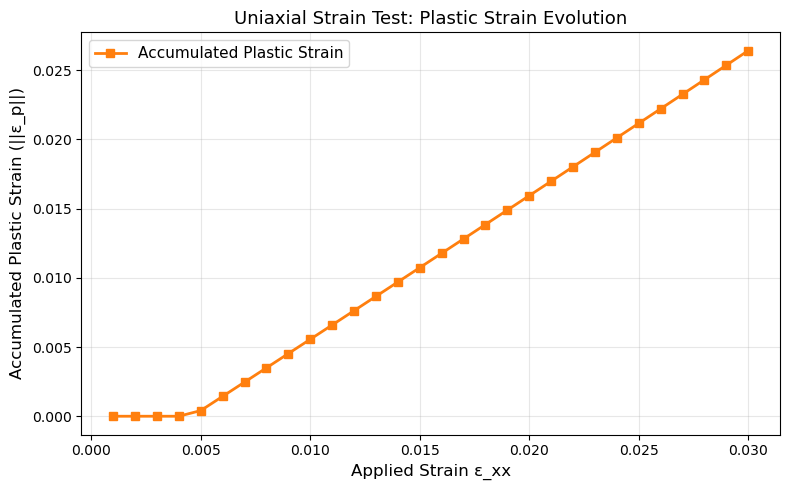

In [4]:
# Plot 1: Stress-Strain Response with Elastic Reference
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eps_xx, sigma_xx / 1e6, "o-", linewidth=2, markersize=6, label="Drucker-Prager (Kratos)")
ax.plot(eps_xx, sigma_elastic_ref / 1e6, "--", linewidth=2, label="Elastic Reference (C11 eps_xx)")
ax.set_xlabel("Applied Strain ε_xx", fontsize=12)
ax.set_ylabel("Axial Stress σ_xx (MPa)", fontsize=12)
ax.set_title("Uniaxial Strain Test: Stress-Strain Response", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Plot 2: Accumulated Plastic Strain Evolution
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eps_xx, alpha_accumulated, "s-", linewidth=2, markersize=6, color="tab:orange", label="Accumulated Plastic Strain")
ax.set_xlabel("Applied Strain ε_xx", fontsize=12)
ax.set_ylabel("Accumulated Plastic Strain (||ε_p||)", fontsize=12)
ax.set_title("Uniaxial Strain Test: Plastic Strain Evolution", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
